```
<13_sky_fusion.ipynb>

제미나이 의존도: 60-70%

이번에는 json 에 정보가 담긴 객체 탐지 데이터셋을 가져왔다.
json.. 다뤄본 적이 거의 없어서 제미나이의 도움을 많이 받았다.
근데 요소에만 접근할 줄만 안다면, 그 이후의 작업은 수월했다.

그나저나 데이터가 약 6만여 개 여서 10에폭을 돌렸는데도 2시간이 넘게 걸렸다...
```

In [2]:
import json
import os
import shutil
import time
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline
import cv2

In [3]:
# JSON 파일 읽어오기 (메모리에 딕셔너리로 로드)
with open('dataset/skyFusion/SkyFusion/train/_annotations.coco.json', 'r') as f:
    data = json.load(f)

# 가장 최상위 key들이 뭐가 있는지 확인해보기
print(f"JSON 최상위 키 목록: {data.keys()}")

# 데이터가 각각 몇 개씩 들어있는지 확인
print(f"총 이미지 수: {len(data['images'])}")
print(f"총 라벨(박스) 수: {len(data['annotations'])}")
print(f"클래스 종류: {data['categories']}\n")


image_dict = {}

images = data['images']
for image in images:
    image_id = image['id']
    file_name = image['file_name']
    height = image['height']
    width = image['width']
    image_dict[image_id] = (file_name, height, width)

# for key, value in list(image_dict.items())[:3]:
    # print(f'{key}: {value}')


# images에는 고유한 id가 있다. 그리고 file_name, height, width를 가지고 있다.
# labels에는 image_id를 가지고 있고, 이것을 images의 id와 연결시켜야 한다.

annotations = data['annotations']

label_save_path = 'dataset/skyFusion/SkyFusion/labels'
os.makedirs(label_save_path, exist_ok=True)

for anno in data['annotations'][:10]:
    img_id = anno['image_id']
    cat_id = anno['category_id'] - 1
    xmin, ymin, box_w, box_h = anno['bbox']

    file_name, img_h, img_w = image_dict[img_id]

    x_center = xmin + (box_w / 2)
    y_center = ymin + (box_h / 2)

    norm_x = x_center / img_w
    norm_y = y_center / img_h
    norm_w = box_w / img_w
    norm_h = box_h / img_h

    pure_name, ext = os.path.splitext(file_name)
    txt_filename = f"{pure_name}.txt"
    save_txt_path = os.path.join(label_save_path, txt_filename)

    line = f"{cat_id} {norm_x:.6f} {norm_y:.6f} {norm_w:.6f} {norm_h:.6f}\n"

    with open(save_txt_path, 'a') as f:
        f.write(line)
print('success')
    
# {'id': 0, 
#  'license': 1, 
#  'file_name': 'P2491__1-0__1200___1764_png_jpg.rf.00342c6c14ae53b3bfadd7995643e1bc.jpg', 
#  'height': 640, 
#  'width': 640, 
#  'date_captured': '2023-12-20T13:55:24+00:00'}

# {'id': 0, 
#  'image_id': 0, 
#  'category_id': 3, 
#  'bbox': [259, 49, 4.8, 9.6], 
#  'area': 46.08, 
#  'segmentation': [[264, 48.8, 259.2, 48.8, 259.2, 58.4, 264, 58.4, 264, 48.8]], 
#  'iscrowd': 0}

JSON 최상위 키 목록: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
총 이미지 수: 2094
총 라벨(박스) 수: 43575
클래스 종류: [{'id': 1, 'name': 'Aircraft'}, {'id': 2, 'name': 'ship'}, {'id': 3, 'name': 'vehicle'}]

success


In [2]:
with open('dataset/skyFusion/SkyFusion/train/_annotations.coco.json', 'r') as f:
    data = json.load(f)

image_dict = {}
for image in data['images']:
    image_id = image['id']
    file_name = image['file_name']
    height = image['height']
    width = image['width']
    image_dict[image_id] = (file_name, height, width)


# 이미지 id별로 라벨 줄(line)들을 모아둘 빈 딕셔너리 생성
labels_per_image = {}

# annotations 루프를 돌면서 메모리(딕셔너리)에 차곡차곡 모으기
for anno in data['annotations']:
    img_id = anno['image_id']

    file_name, img_height, img_width = image_dict[img_id]

    if img_id not in labels_per_image:
        labels_per_image[img_id] = []

    category_id = anno['category_id'] - 1
    xmin, ymin, box_w, box_h = anno['bbox']

    x_center = xmin + (box_w / 2)
    y_center = ymin + (box_h / 2)

    norm_x = x_center / img_width
    norm_y = y_center / img_height
    norm_w = box_w / img_width
    norm_h = box_h / img_height

    line = f'{category_id} {norm_x:.6f} {norm_y:.6f} {norm_w:.6f} {norm_h:.6f}'
    
    labels_per_image[img_id].append(line)

save_txt_path = 'dataset/skyFusion/SkyFusion/train_labels'
os.makedirs(save_txt_path, exist_ok=True)
# 모인 딕셔너리를 바탕으로 이미지당 단 한 번만 'w' 모드로 저장
for img_id, lines in labels_per_image.items():
    file_name, _, _ = image_dict[img_id]
    pure_name, ext = os.path.splitext(file_name)
    txt_name = f'{pure_name}.txt'
    save_full_txt_path = os.path.join(save_txt_path, txt_name)
    with open(save_full_txt_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')

print('finished')

finished


In [25]:
split_data = ["train", "valid", "test"]
for split_type in split_data:
    count = 0
    label_save_path = f'dataset/skyFusion/SkyFusion/{split_type}_labels'
    os.makedirs(label_save_path, exist_ok=True)
    with open(f'dataset/skyFusion/SkyFusion/{split_type}/_annotations.coco.json') as f:
        data = json.load(f)

    image_dict = {}
    for image in data['images']:
        image_id = image['id']
        image_dict[image_id] = (image['file_name'], image['height'], image['width'])

    annotations = data['annotations']
    for anno in annotations:
        image_id = anno['image_id']
        file_name, img_height, img_width = image_dict[image_id]

        category_id = anno['category_id'] - 1

        xmin, ymin, box_w, box_h = anno['bbox']

        center_x = xmin + (box_w / 2)
        center_y = ymin + (box_h / 2)

        norm_x = center_x / img_width
        norm_y = center_y / img_height
        norm_w = box_w / img_width
        norm_h = box_h / img_height

        line = f'{category_id} {norm_x:.6f} {norm_y:.6f} {norm_w:.6f} {norm_h:.6f}\n'
        pure_name, ext = os.path.splitext(file_name)
        save_txt_path = os.path.join(label_save_path, f'{pure_name}.txt')
        with open(save_txt_path, 'a') as f:
            f.write(line)

        count += 1
    
    print(f'{split_type} count: {count}')
print('success')

train count: 43575
valid count: 8387
test count: 11751
success


In [33]:
# 이미지는 images, 라벨은 labels 폴더에 넣기(shutil.copy)
common_path = 'dataset/skyFusion'

for split_type in split_data:
    count = 0
    dest_images_path = os.path.join(common_path, f'{split_type}/images')
    dest_labels_path = os.path.join(common_path, f'{split_type}/labels')

    os.makedirs(images_path, exist_ok=True)
    os.makedirs(labels_path, exist_ok=True)

    src_image_path = os.path.join(common_path, f'SkyFusion/{split_type}')
    src_label_path = os.path.join(common_path, f'SkyFusion/{split_type}_labels')

    src_image_list = [f for f in os.listdir(src_image_path) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    set_src_image = set(src_image_list)

    src_label_list = [f for f in os.listdir(src_label_path) if f.endswith(('.txt'))]
    set_src_label = set(src_label_list)

    for image in set_src_image:
        pure_name, ext = os.path.splitext(image)
        txt_name = f'{pure_name}.txt'
        if txt_name in set_src_label:
            full_src_image_path = os.path.join(src_image_path, image)
            full_dest_image_path = os.path.join(dest_images_path, image)
            shutil.copy(full_src_image_path, full_dest_image_path)
            full_src_label_path = os.path.join(src_label_path, txt_name)
            full_dest_label_path = os.path.join(dest_labels_path, txt_name)
            shutil.copy(full_src_label_path, full_dest_label_path)
            count += 1

    print(f'{split_type} count: {count}')

train count: 2094
valid count: 449
test count: 449


In [4]:
print(f"클래스 종류: {data['categories']}\n")

print(type(data['categories']))
new_dict = {}
for i, item in enumerate(data['categories']):
    new_dict[i] = item['name']
    # print(item['name'])

print(new_dict)
print(list(new_dict.values()))

yaml_path = 'dataset/skyFusion/data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write('train: ../train/images\n')
    f.write('val: ../valid/images\n')
    f.write('test: ../test/images\n')
    f.write('\n')
    f.write(f'nc: {len(new_dict)}\n')
    f.write(f'names: {list(new_dict.values())}')

클래스 종류: [{'id': 1, 'name': 'Aircraft'}, {'id': 2, 'name': 'ship'}, {'id': 3, 'name': 'vehicle'}]

<class 'list'>
{0: 'Aircraft', 1: 'ship', 2: 'vehicle'}
['Aircraft', 'ship', 'vehicle']


In [5]:
model = YOLO('yolov8n.pt')

current_dir = os.getcwd()

start_time = time.time()
result = model.train(
    data=yaml_path, 
    epochs=10, 
    imgsz=640, 
    device='mps',
    project=os.path.join(current_dir, 'runs'), 
    name='skyFusion'
)

elapsed_time = int(time.time() - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f'{mins}: {secs}')

New https://pypi.org/project/ultralytics/8.4.105 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/skyFusion/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=skyFusion, nbs=64

In [3]:
def inspect_detection(image_path, conf_threshold=0.45, iou_threshold=0.4):
    model = YOLO('runs/skyFusion/weights/best.pt')

    preds = model.predict(
        source=image_path, 
        conf=conf_threshold, 
        iou=iou_threshold, 
        device='mps'
    )

    result = preds[0]
    annotated_img_bgr = result.plot()
    img_rgb = cv2.cvtColor(annotated_img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f'Conf: {conf_threshold} | IoU: {iou_threshold}')
    plt.axis('off')
    plt.show()


image 1/1 /Users/jeongjaehun/Github/03_object_detection/dataset/skyFusion/test/images/014de911-7810-4f7d-8967-3e5402209f4a_1060_0_jpg.rf.387550d1c7773e2df29177609a015210.jpg: 640x640 17 Aircrafts, 7.9ms
Speed: 1.3ms preprocess, 7.9ms inference, 17.3ms postprocess per image at shape (1, 3, 640, 640)


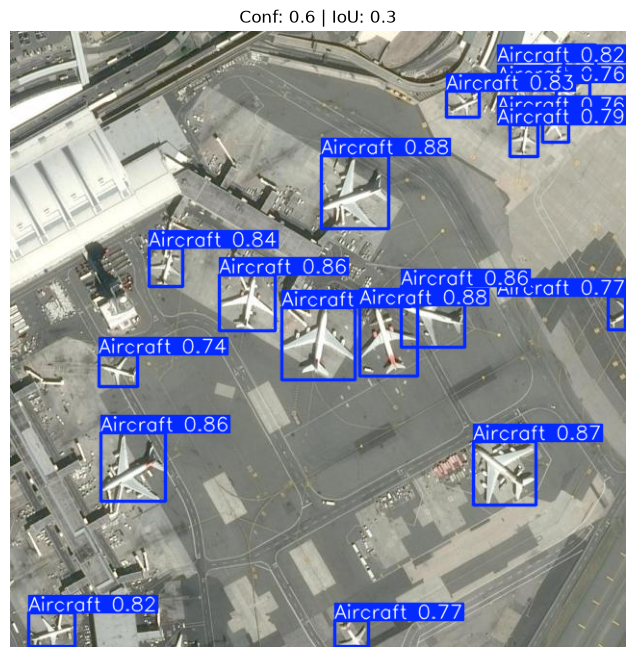

In [7]:
image_path = 'dataset/skyFusion/test/images/014de911-7810-4f7d-8967-3e5402209f4a_1060_0_jpg.rf.387550d1c7773e2df29177609a015210.jpg'
inspect_detection(image_path, conf_threshold=0.6, iou_threshold=0.3)